<a href="https://colab.research.google.com/github/babi00/ai4biological-pattern/blob/main/download_and_analyze_from_iNaturalist/annotate_unnotated_data_v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline: Image -> class aware augmentations -> Image embedding extraction (BioCLIP or ResNet) -> SMOTE on embeddings -> CLassifier
## Modified version: different data augmention (depending on class frequency) + SMOTE augmentation
## Modello che utilizza multi binary classes, BioCLIP come extractor embedding e semplice classificatore
(Download delle immagini in locale)

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.transforms import functional as TF
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, multilabel_confusion_matrix, confusion_matrix
import seaborn as sns
import requests
from io import BytesIO
from google.colab import drive
import time
import tqdm
!pip install open_clip_torch
import open_clip
from collections import Counter
from imblearn.over_sampling import SMOTE
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

!apt-get install git

# Clone the repository without checking out files
!git clone --filter=blob:none --no-checkout https://github.com/babi00/ai4biological-pattern.git
%cd ai4biological-pattern

# Enable sparse checkout
!git sparse-checkout init --cone



drive.mount('/content/drive')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.12).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
fatal: destination path 'ai4biological-pattern' already exists and is not an empty directory.
/content/ai4biological-pattern
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#1.Load and prepare data
class PlantPhenologyDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, preprocess=None, minority_classes=None, strong_transform=None, light_transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform
        self.preprocess = preprocess
        self.minority_classes = minority_classes or []
        self.strong_transform = strong_transform
        self.light_transform = light_transform

        #possible phenology states and creation of label mapping
        if 'value' in dataframe.columns and dataframe['value'].notna().any():
            self.phenology_classes = sorted(dataframe['value'].dropna().unique())
            self.class_to_idx = {c: i for i, c in enumerate(self.phenology_classes)}
        else:
            self.phenology_classes = []
            self.class_to_idx = {}


    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
      row = self.dataframe.iloc[idx]
      obs_id = row['observation_id']

      #try to load images: they can have multiple formats
      extensions = [".jpeg", ".jpg", ".JPG", ".png", ".PNG"]
      variants = [f"{obs_id}_{i}{ext}" for i in range(21) for ext in extensions]

      image = None


      for filename in variants:
          local_path = os.path.join(self.img_dir, filename) #locally downloaded
          if os.path.exists(local_path):
              try:
                image = Image.open(local_path).convert("RGB")
                break
              except Exception as e:
                  print(f"Failed to open image {filename}: {e}")
              except:
                  continue

      if image is None:
          raise FileNotFoundError(f"Could not load any image for observation ID {obs_id}")

      label = row["value"] if "value" in row and pd.notna(row["value"]) else None

      #apply class-aware transofrms
      if self.strong_transform and self.light_transform and label is not None:
          if label in self.minority_classes:
              image = self.strong_transform(image)
          else:
              image = self.light_transform(image)
      elif self.transform:
          image = self.transform(image)


      #one-hot encoded label vector for binary classifications
      label_vector = torch.zeros(len(self.phenology_classes))
      if pd.notna(row['value']):
          for i, phenology_class in enumerate(self.phenology_classes):
              #if this is the correct class, set to 1
              if row['value'] == phenology_class:
                  label_vector[i] = 1


      #BioCLIP needs its own standard format: we need to convert images created
      if self.preprocess:
          if isinstance(image, torch.Tensor):
              image = TF.to_pil_image(image)
          processed = self.preprocess(image)
          return processed, label_vector, obs_id

      else:
          return image, label_vector, obs_id


#identify classes that are less represented
def identify_minority_classes(df, label_col='value', threshold=0.5):
    distribution = Counter(df[label_col])
    max_count = max(distribution.values())
    minority_classes = [key for key, value in distribution.items() if value < threshold * max_count]
    print(f"max count: {max_count}")
    print(f"minority classes: {minority_classes}")
    print(f"distribution: {distribution}")
    return minority_classes

#Data loading function for a single specie
def load_data_single_specie(csv_path, img_dir, use_bioclip=True, preprocess=None):
    df = pd.read_csv(csv_path)

    #Split into labeled and unlabeled data
    labeled_df = df[df['value'].notna()].copy()
    unlabeled_df = df[df['value'].isna()].copy()

    print(f"Total observations: {len(df)}")
    print(f"Labeled observations: {len(labeled_df)}")
    print(f"Unlabeled observations: {len(unlabeled_df)}")

    #Split labeled data into train and validation sets
    train_df, val_df = train_test_split(labeled_df, test_size=0.2, random_state=42, stratify=labeled_df['value'])

    print(f"Training set size: {len(train_df)}")
    print(f"Validation set size: {len(val_df)}")


    minority_classes = identify_minority_classes(train_df)


    #augmentation policies
    if use_bioclip and preprocess:
        #define strong and light augmentations (as tensors)
        strong_transform = transforms.Compose([
            transforms.RandomApply([transforms.ColorJitter(0.5, 0.5, 0.5, 0.2)], p=0.8),
            transforms.RandomAffine(degrees=20, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=10),
            transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomResizedCrop(224, scale=(0.4, 1.0), ratio=(0.75, 1.33)),
        ])
        light_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
        ])
        train_dataset = PlantPhenologyDataset(train_df, img_dir,preprocess=preprocess,minority_classes=minority_classes,
                                              strong_transform=strong_transform,light_transform=light_transform)
        val_dataset = PlantPhenologyDataset(val_df, img_dir, preprocess=preprocess)
        unlabeled_dataset = PlantPhenologyDataset(unlabeled_df, img_dir, preprocess=preprocess)

    else:
        #classic torchvision-based transforms with strong and light augmentation
        strong_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
            transforms.RandomAffine(degrees=25, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=10),
            transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(20),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
        ])
        light_transform = transforms.Compose([
          transforms.Resize((224, 224)),
          transforms.RandomHorizontalFlip(),
          transforms.ToTensor(),
          transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225])
      ])

        val_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])

        train_dataset = PlantPhenologyDataset(train_df, img_dir, minority_classes=minority_classes,
                                              strong_transform=strong_transform, ligth_transform=light_transform)
        val_dataset = PlantPhenologyDataset(val_df, img_dir, transform=val_transform)
        unlabeled_dataset = PlantPhenologyDataset(unlabeled_df, img_dir, transform=val_transform)


    #dataloaders
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16)
    unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=16)

    return train_loader, val_loader, unlabeled_loader, train_dataset.phenology_classes, minority_classes

In [ ]:
#2.Define the embedding extractor:
#ResNet without the last FC layer
def get_resnet_embeddings_extractor_model(num_classes):
    print("-> Getting resnet embeddings extractor model...")
    #Use a pre-trained ResNet18 model
    model = models.resnet18(weights='IMAGENET1K_V1')

    #Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    embeddings_extractor= nn.Sequential(*list(model.children())[:-1]) #removes the last FC layer

    return embeddings_extractor

#BioCLIP model
def get_bioclip_embeddings_extractor_model(device):
    print("-> Getting bioclip embeddings extractor model...")
    model, preprocess, _ = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip')
    model.to(device)
    model.eval()
    return model, preprocess

In [ ]:
#3.Extract embeddings using the embeddings_extractor and create the DataLoader
def extract_embeddings(dataloader, embeddings_extractor, device, use_bioclip=True, use_smote=True, minority_classes=None, phenology_classes=None):
    print("-> Extracting embeddings...")
    embeddings_extractor.eval()
    all_embeddings = []
    all_labels = []
    all_ids = []

    if use_bioclip:
      with torch.no_grad():
        for images, labels, obs_id in dataloader:
            images = images.to(device)
            embeddings = embeddings_extractor.encode_image(images)
            embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)  # Optional: normalize
            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels)
            all_ids.extend(obs_id)

    else:
      with torch.no_grad():
        for images, labels, obs_id in dataloader:
            images = images.to(device)
            embeddings = embeddings_extractor(images).view(images.size(0), -1)
            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels)
            all_ids.extend(obs_id)

    embeddings_tensors = torch.cat(all_embeddings, dim=0).to(device)
    labels_tensors = torch.cat(all_labels, dim=0).to(device)
    obs_id_tensor = torch.tensor(all_ids).to(device)

    if use_smote and minority_classes is not None and phenology_classes is not None:
        print("Using SMOTE: generating synthetic embeddings...")
        embeddings_tensors, labels_tensors = apply_smote_to_embeddings(embeddings_tensors, labels_tensors, device, minority_classes, phenology_classes)
        # Since SMOTE generates synthetic samples, obs_id_tensor needs to be adjusted accordingly.
        # For simplicity, we'll assign -1 to synthetic samples.
        num_synthetic = embeddings_tensors.size(0) - obs_id_tensor.size(0)
        synthetic_ids = torch.full((num_synthetic,), -1, dtype=torch.long).to(device)
        obs_id_tensor = torch.cat([obs_id_tensor, synthetic_ids], dim=0)



    dataset = torch.utils.data.TensorDataset(embeddings_tensors, labels_tensors, obs_id_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

    embedding_size = embeddings_tensors.shape[1] #useful for classifier

    return loader, embedding_size

In [ ]:
#4.SMOTE: apply SMOTE to extracted embeddings to further balance classes
def apply_smote_to_embeddings(embeddings, labels, device, minority_classes, phenology_classes):

# Convert one-hot encoded labels to class indices
    labels_indices = torch.argmax(labels, dim=1).cpu().numpy()
    embeddings_np = embeddings.cpu().numpy()

    print("Original labels indices:", labels_indices)
    print("Minority classes:", minority_classes)

    # Get indices of minority classes in the phenology_classes list
    minority_class_indices_set = set([phenology_classes.index(cls) for cls in minority_classes])
    print("Minority class indices:", minority_class_indices_set)

    # Count current class distribution
    from collections import Counter
    original_distribution = Counter(labels_indices)
    print("Original class distribution:", dict(original_distribution))

    # Determine target count (you can adjust this strategy)
    # Option 1: Balance to the largest minority class count
    minority_counts = {cls_idx: count for cls_idx, count in original_distribution.items()
                      if cls_idx in minority_class_indices_set}

    if not minority_counts:
        print("Warning: No minority class samples found. Skipping SMOTE.")
        return embeddings, labels

    # Option 2: Balance to a reasonable target (avoid extreme oversampling)
    max_minority_count = max(minority_counts.values())
    majority_counts = {cls_idx: count for cls_idx, count in original_distribution.items()
                      if cls_idx not in minority_class_indices_set}
    min_majority_count = min(majority_counts.values()) if majority_counts else max_minority_count


    # Option 3: Balance to majority class count (uncomment if preferred)
    # target_count = int(max_majority_count)

    # Create sampling strategy dictionary - only oversample minority classes
    sampling_strategy = {}
    for cls_idx in minority_class_indices_set:
        current_count = original_distribution.get(cls_idx, 0)
        if current_count > 0 and current_count < min_majority_count:
            target_count = min(min(int(min_majority_count * 0.5),int(current_count * 3)), min_majority_count)
            sampling_strategy[cls_idx] = int(target_count)  # Ensure integer values

    if not sampling_strategy:
        print("Warning: No minority classes need oversampling. Skipping SMOTE.")
        return embeddings, labels

    print("SMOTE sampling strategy:", sampling_strategy)

    # Apply SMOTE with specific sampling strategy
    smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)

    try:
        embeddings_resampled, labels_resampled = smote.fit_resample(embeddings_np, labels_indices)
    except ValueError as e:
        print(f"SMOTE failed: {e}")
        print("This might happen if there aren't enough samples for k-neighbors. Skipping SMOTE.")
        return embeddings, labels

    # Convert back to tensors
    embeddings_resampled = torch.tensor(embeddings_resampled, dtype=torch.float32).to(device)
    labels_resampled = torch.tensor(labels_resampled, dtype=torch.long)

    # Convert to one-hot encoding
    num_classes = labels.size(1)
    labels_resampled = F.one_hot(labels_resampled, num_classes=num_classes).float().to(device)

    # Print final distribution
    final_distribution = Counter(torch.argmax(labels_resampled, dim=1).cpu().numpy())
    print("Final class distribution after SMOTE:", dict(final_distribution))



    return embeddings_resampled, labels_resampled

In [ ]:
#5.Construct a classifier that given the embedding it predicts the phenology state
class PhenologyClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, num_classes=4):
        super().__init__()
        self.classifier = nn.Sequential(
              nn.Linear(input_dim, hidden_dim),
              nn.ReLU(),
              nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

In [ ]:
#5. Training function
def train_classifier(classifier, train_loader, val_loader, criterion, optimizer, device, folder_name, phenology_classes, model_name, num_epochs=10, lr=0.001):
    print("-> Training classifier...")
    classifier.to(device)
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc_per_class': [], 'val_acc_per_class': [], 'train_acc': [],'val_acc': []}
    num_classes = len(phenology_classes)

    for epoch in range(num_epochs):
        classifier.train()
        running_loss = 0.0
        correct = torch.zeros(num_classes).to(device)
        total = torch.zeros(num_classes).to(device)

        for embeddings, labels, _ in train_loader:
            #zero the parameter gradients
            optimizer.zero_grad()

            labels = labels.to(device) #move labels to the correct device

            #forward pass
            outputs = classifier(embeddings)
            loss = criterion(outputs, labels.float())

            #backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * embeddings.size(0)

            probs = torch.sigmoid(outputs)
            preds = torch.zeros_like(probs)
            top_class = torch.argmax(probs, dim=1) #only the class with the highest probability is marked 1
            preds[range(probs.size(0)), top_class] = 1
            correct += (preds == labels).sum(dim=0)
            total += labels.size(0)


        #track statistics to draw graph
        epoch_train_loss = running_loss / total.sum().item()
        epoch_train_acc_per_class = (correct / total).cpu().numpy()
        epoch_train_acc = correct.sum().item() / total.sum().item()
        epoch_val_acc = correct.sum().item() / total.sum().item()
        history['train_loss'].append(epoch_train_loss)
        history['train_acc_per_class'].append(epoch_train_acc_per_class)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        #validation phase
        classifier.eval()
        running_loss = 0.0
        correct = torch.zeros(num_classes).to(device)
        total = torch.zeros(num_classes).to(device)

        with torch.no_grad():
            for embeddings, labels, _ in val_loader:
                labels = labels.to(device) #move labels to the correct device

                outputs = classifier(embeddings)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * embeddings.size(0)

                probs = torch.sigmoid(outputs)
                preds = torch.zeros_like(probs)
                top_class = torch.argmax(probs, dim=1) #only the class with the highest probability is marked 1
                preds[range(probs.size(0)), top_class] = 1
                correct += (preds == labels).sum(dim=0)
                total += labels.size(0)

        #track statistics to draw graph
        epoch_val_loss = running_loss / total.sum().item()
        epoch_val_acc_per_class = (correct.float() / total).cpu().numpy() # Ensure correct is float for division
        history['val_loss'].append(epoch_val_loss)
        history['val_acc_per_class'].append(epoch_val_acc_per_class)

        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {epoch_train_loss:.4f}, '
              f'Validation Loss: {epoch_val_loss:.4f}')

    torch.save(classifier.state_dict(), f'{folder_name}.pth')
    google_drive_path = f'/content/drive/MyDrive/TESI - PoliTO/phenology_models/{model_name}{folder_name}.pth'
    torch.save(classifier.state_dict(), google_drive_path)
    classifier.load_state_dict(torch.load(f'{folder_name}.pth'))
    return classifier, history

In [ ]:
#6. Evaluate the model
def evaluate_classifier(classifier, dataloader, device, phenology_classes, folder_name, model_name):
    print("-> Evaluating classifier...")
    classifier.eval()
    all_preds = []
    all_labels = []
    all_ids = []

    with torch.no_grad():
        for embeddings, labels, obs_ids in dataloader:
            labels = labels.to(device) #move labels to the correct device

            outputs = classifier(embeddings)
            probs = torch.sigmoid(outputs)
            preds = torch.zeros_like(probs)
            top_class = torch.argmax(probs, dim=1) #only the class with the highest probability is marked 1
            preds[range(probs.size(0)), top_class] = 1

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            all_ids.extend(obs_ids.cpu())



    #confusion matrix
    all_preds = torch.cat(all_preds, dim=0).cpu().numpy().astype(int)
    all_labels = torch.cat(all_labels, dim=0).cpu().numpy().astype(int)

    print(classification_report(all_labels, all_preds, target_names=phenology_classes))

    cm = multilabel_confusion_matrix(all_labels, all_preds)
    class_names = phenology_classes

    n_classes = len(class_names)
    cols = 2
    rows = (n_classes + 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))
    axes = axes.flatten()

    for i in range(n_classes):
        ax = axes[i]
        cmat = cm[i]
        im = ax.imshow(cmat, interpolation='nearest', cmap=plt.cm.Blues)
        ax.set_title(f'"{class_names[i]}"')
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Not Present', 'Present'])
        ax.set_yticklabels(['Not Present', 'Present'])
        ax.set_ylabel('True')
        ax.set_xlabel('Predicted')

        thresh = cmat.max() / 2
        for j in range(2):
            for k in range(2):
                ax.text(k, j, format(cmat[j, k], 'd'),
                        ha="center", va="center",
                        color="white" if cmat[j, k] > thresh else "black")

    # Hide unused subplots if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig(f'{model_name}all_confusion_matrices_{folder_name}.png')
    plt.show()

    #aggregated confusion matrix
    aggregated_cm = confusion_matrix(
        np.argmax(all_labels, axis=1),
        np.argmax(all_preds, axis=1)
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(aggregated_cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=phenology_classes, yticklabels=phenology_classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Aggregated Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'aggregated_confusion_matrix_{folder_name}.png')
    plt.show()


    #Create a DataFrame with results
    results_df = pd.DataFrame({
        'observation_id': all_ids,
        'true_phenology': [phenology_classes[i] for i in np.argmax(all_labels, axis=1)],
        'predicted_phenology': [phenology_classes[i] for i in np.argmax(all_preds, axis=1)]
    })

    return results_df

In [ ]:
#7. Make predictions on unlabeled data
def predict_unlabeled(classifier, dataloader, device, phenology_classes):
    print("-> Predicting unlabeled data...")
    classifier.eval()
    all_preds = []
    all_ids = []

    with torch.no_grad():
        for embeddings, labels, obs_ids in dataloader:
            outputs = classifier(embeddings)
            probs = torch.sigmoid(outputs)
            preds = torch.zeros_like(probs)
            top_class = torch.argmax(probs, dim=1) #only the class with the highest probability is marked 1
            preds[range(probs.size(0)), top_class] = 1

            all_preds.extend(preds.cpu())
            all_ids.extend(obs_ids.cpu())

    #Create a DataFrame with predictions
    predictions_df = pd.DataFrame({
        'observation_id': all_ids,
        'predicted_phenology': [phenology_classes[np.argmax(pred)] for pred in all_preds]
    })

    return predictions_df

In [ ]:
folder_name='PROVA_fragola_verde'
use_bioclip = True
start_time = time.time()

#to download from github
#github_repository = 'https://raw.githubusercontent.com/babi00/ai4biological-pattern/download_and_analyze_iNaturalist/download_and_analyze_from_iNaturalist/PROVA_fragola_verde/'
#to retrieve from locally downloaded repository
github = '/content/ai4biological-pattern/download_and_analyze_from_iNaturalist'
github_repository = f'{github}/data/{folder_name}/'
csv_path = f'{github_repository}annotations_detailed_{folder_name}.csv'
img_dir = f'{github_repository}inat_photos/'

if not os.path.isdir(github_repository): #check if data has already been downloaded
    !git sparse-checkout set download_and_analyze_from_iNaturalist/data/{folder_name}
    !git checkout main

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

#embedding extractor model
if use_bioclip:
    embeddings_extractor, preprocess = get_bioclip_embeddings_extractor_model(device)
    embeddings_extractor = embeddings_extractor.to(device)
else:
    embeddings_extractor = get_resnet_embeddings_extractor_model()
    embeddings_extractor = embeddings_extractor.to(device)
    preprocess = None

#Load data
train_loader, val_loader, unlabeled_loader, phenology_classes = load_data_single_specie(csv_path, img_dir, use_bioclip=use_bioclip, preprocess=preprocess)


#extract embeddings and save in dataloaders
embeddings_train_loader, input_size = extract_embeddings(train_loader, embeddings_extractor, device)
embeddings_val_loader, _ = extract_embeddings(val_loader, embeddings_extractor, device, use_smote=False)
embeddings_unlabeled_loader, _ = extract_embeddings(unlabeled_loader, embeddings_extractor, device, use_smote=False)

#initialize classifier
classifier = PhenologyClassifier(input_size)

#Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss() #for multiple binary classification
optimizer = optim.Adam(filter(lambda p: p.requires_grad, classifier.parameters()), lr=0.001) #make sure than the optimizer does not modify all layers: only those earlier specified (not freezed)

#to save model and figures
model_name = "bioclip_" if use_bioclip else "resnet_"
#Train model
classifier, history = train_classifier(classifier, embeddings_train_loader, embeddings_val_loader, criterion, optimizer, device, folder_name, phenology_classes, model_name, num_epochs=15)

# Plot training history for accuracy per class
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
for i in range(len(phenology_classes)):
    acc = [epoch[i] for epoch in history['train_acc_per_class']]
    plt.plot(acc, label=f'Train - {phenology_classes[i]}')
plt.xlabel('Epoch')
plt.ylabel('Train Accuracy per Class')
plt.legend()

plt.subplot(2, 1, 2)
for i in range(len(phenology_classes)):
    acc = [epoch[i] for epoch in history['val_acc_per_class']]
    plt.plot(acc, label=f'Val - {phenology_classes[i]}')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy per Class')
plt.legend()

plt.tight_layout()
plt.savefig(f'{model_name}training_accuracy_per_class_{folder_name}.png')
plt.show()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(f'{model_name}training_history_{folder_name}.png')
plt.show()

#Evaluate model on validation set
results_df = evaluate_classifier(classifier, embeddings_val_loader, device, phenology_classes, folder_name, model_name)
results_df.to_csv(f'{model_name}validation_results_{folder_name}.csv', index=False)

#Make predictions on unlabeled data
predictions_df = predict_unlabeled(classifier, embeddings_unlabeled_loader, device, phenology_classes)
predictions_df["observation_id"] = predictions_df["observation_id"].apply(lambda x: x.item() if isinstance(x, torch.Tensor) else x)
predictions_df.to_csv(f'{model_name}unlabeled_predictions_{folder_name}.csv', index=False)

#Merge predictions with original CSV
original_df = pd.read_csv(csv_path)

#Only update rows where Plant Phenology value is missing
mask = (original_df['term'] == 'Plant Phenology') & (original_df['value'].isna())

#Create a dictionary mapping observation_id to predicted phenology
pred_dict = dict(zip(predictions_df['observation_id'], predictions_df['predicted_phenology']))

#Update and save original DataFrame
original_df.loc[mask, 'value'] = original_df.loc[mask, 'observation_id'].map(pred_dict)

original_df.to_csv(f'{model_name}updated_data_{folder_name}.csv', index=False)
google_drive_path = f'/content/drive/MyDrive/TESI - PoliTO/{model_name}updated_data_{folder_name}.csv'
original_df.to_csv(google_drive_path, index=False)

print("Successfully updated phenology data!")

Using device: cuda
-> Getting bioclip embeddings extractor model...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Total observations: 10487
Labeled observations: 781
Unlabeled observations: 9706
Training set size: 624
Validation set size: 157
-> Extracting embeddings...
Using SMOTE: generating synthetic embeddings...
NUMBER OF CLASSE:  4
-> Extracting embeddings...
-> Extracting embeddings...


KeyboardInterrupt: 

In [ ]:
def create_model_and_predict(folder_name, use_bioclip=True):

    start_time = time.time()

    #to download from github
    #github_repository = 'https://raw.githubusercontent.com/babi00/ai4biological-pattern/download_and_analyze_iNaturalist/download_and_analyze_from_iNaturalist/PROVA_fragola_verde/'
    #to retrieve from locally downloaded repository
    github = '/content/ai4biological-pattern/download_and_analyze_from_iNaturalist'
    github_repository = f'{github}/data/{folder_name}/'
    csv_path = f'{github_repository}annotations_detailed_{folder_name}.csv'
    img_dir = f'{github_repository}inat_photos/'

    if not os.path.isdir(github_repository): #check if data has already been downloaded
        !git sparse-checkout set download_and_analyze_from_iNaturalist/data/{folder_name}
        !git checkout main

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    #embedding extractor model
    if use_bioclip:
        embeddings_extractor, preprocess = get_bioclip_embeddings_extractor_model(device)
        embeddings_extractor = embeddings_extractor.to(device)
    else:
        embeddings_extractor = get_resnet_embeddings_extractor_model()
        embeddings_extractor = embeddings_extractor.to(device)
        preprocess = None

    #Load data
    train_loader, val_loader, unlabeled_loader, phenology_classes, minority_classes = load_data_single_specie(csv_path, img_dir, use_bioclip=use_bioclip, preprocess=preprocess)


    #extract embeddings and save in dataloaders
    embeddings_train_loader, input_size = extract_embeddings(train_loader, embeddings_extractor, device, minority_classes=minority_classes, phenology_classes=phenology_classes)
    embeddings_val_loader, _ = extract_embeddings(val_loader, embeddings_extractor, device, use_smote=False)
    embeddings_unlabeled_loader, _ = extract_embeddings(unlabeled_loader, embeddings_extractor, device, use_smote=False)

    #initialize classifier
    classifier = PhenologyClassifier(input_size)

    #Define loss function and optimizer
    criterion = nn.BCEWithLogitsLoss() #for multiple binary classification
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, classifier.parameters()), lr=0.001) #make sure than the optimizer does not modify all layers: only those earlier specified (not freezed)

    #to save model and figures
    model_name = "bioclip_" if use_bioclip else "resnet_"
    #Train model
    classifier, history = train_classifier(classifier, embeddings_train_loader, embeddings_val_loader, criterion, optimizer, device, folder_name, phenology_classes, model_name, num_epochs=15)

    # Plot training history for accuracy per class
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    for i in range(len(phenology_classes)):
        acc = [epoch[i] for epoch in history['train_acc_per_class']]
        plt.plot(acc, label=f'Train - {phenology_classes[i]}')
    plt.xlabel('Epoch')
    plt.ylabel('Train Accuracy per Class')
    plt.legend()

    plt.subplot(2, 1, 2)
    for i in range(len(phenology_classes)):
        acc = [epoch[i] for epoch in history['val_acc_per_class']]
        plt.plot(acc, label=f'Val - {phenology_classes[i]}')
    plt.xlabel('Epoch')
    plt.ylabel('Val Accuracy per Class')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{model_name}training_accuracy_per_class_{folder_name}.png')
    plt.show()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{model_name}training_history_{folder_name}.png')
    plt.show()

    #Evaluate model on validation set
    results_df = evaluate_classifier(classifier, embeddings_val_loader, device, phenology_classes, folder_name, model_name)
    results_df.to_csv(f'{model_name}validation_results_{folder_name}.csv', index=False)

    #Make predictions on unlabeled data
    predictions_df = predict_unlabeled(classifier, embeddings_unlabeled_loader, device, phenology_classes)
    predictions_df["observation_id"] = predictions_df["observation_id"].apply(lambda x: x.item() if isinstance(x, torch.Tensor) else x)
    predictions_df.to_csv(f'{model_name}unlabeled_predictions_{folder_name}.csv', index=False)

    #Merge predictions with original CSV
    original_df = pd.read_csv(csv_path)

    #Only update rows where Plant Phenology value is missing
    mask = (original_df['term'] == 'Plant Phenology') & (original_df['value'].isna())

    #Create a dictionary mapping observation_id to predicted phenology
    pred_dict = dict(zip(predictions_df['observation_id'], predictions_df['predicted_phenology']))

    #Update and save original DataFrame
    original_df.loc[mask, 'value'] = original_df.loc[mask, 'observation_id'].map(pred_dict)

    original_df.to_csv(f'{model_name}updated_data_{folder_name}.csv', index=False)
    google_drive_path = f'/content/drive/MyDrive/TESI - PoliTO/{model_name}updated_data_{folder_name}.csv'
    original_df.to_csv(google_drive_path, index=False)

    print("Successfully updated phenology data!")

Using device: cuda
-> Getting bioclip embeddings extractor model...
Total observations: 10487
Labeled observations: 781
Unlabeled observations: 9706
Training set size: 624
Validation set size: 157
-> Extracting embeddings...
Using SMOTE: generating synthetic embeddings...
NUMBER OF CLASSE:  4
-> Extracting embeddings...
-> Extracting embeddings...
-> Training classifier...
Epoch 1/15: Train Loss: 0.1350, Validation Loss: 0.1079
Epoch 2/15: Train Loss: 0.0758, Validation Loss: 0.0835
Epoch 3/15: Train Loss: 0.0469, Validation Loss: 0.0762
Epoch 4/15: Train Loss: 0.0341, Validation Loss: 0.0804
Epoch 5/15: Train Loss: 0.0265, Validation Loss: 0.0807
Epoch 6/15: Train Loss: 0.0212, Validation Loss: 0.0863
Epoch 7/15: Train Loss: 0.0177, Validation Loss: 0.0874
Epoch 8/15: Train Loss: 0.0148, Validation Loss: 0.0894
Epoch 9/15: Train Loss: 0.0126, Validation Loss: 0.0919
Epoch 10/15: Train Loss: 0.0109, Validation Loss: 0.0944
Epoch 11/15: Train Loss: 0.0097, Validation Loss: 0.0977
Epoch 

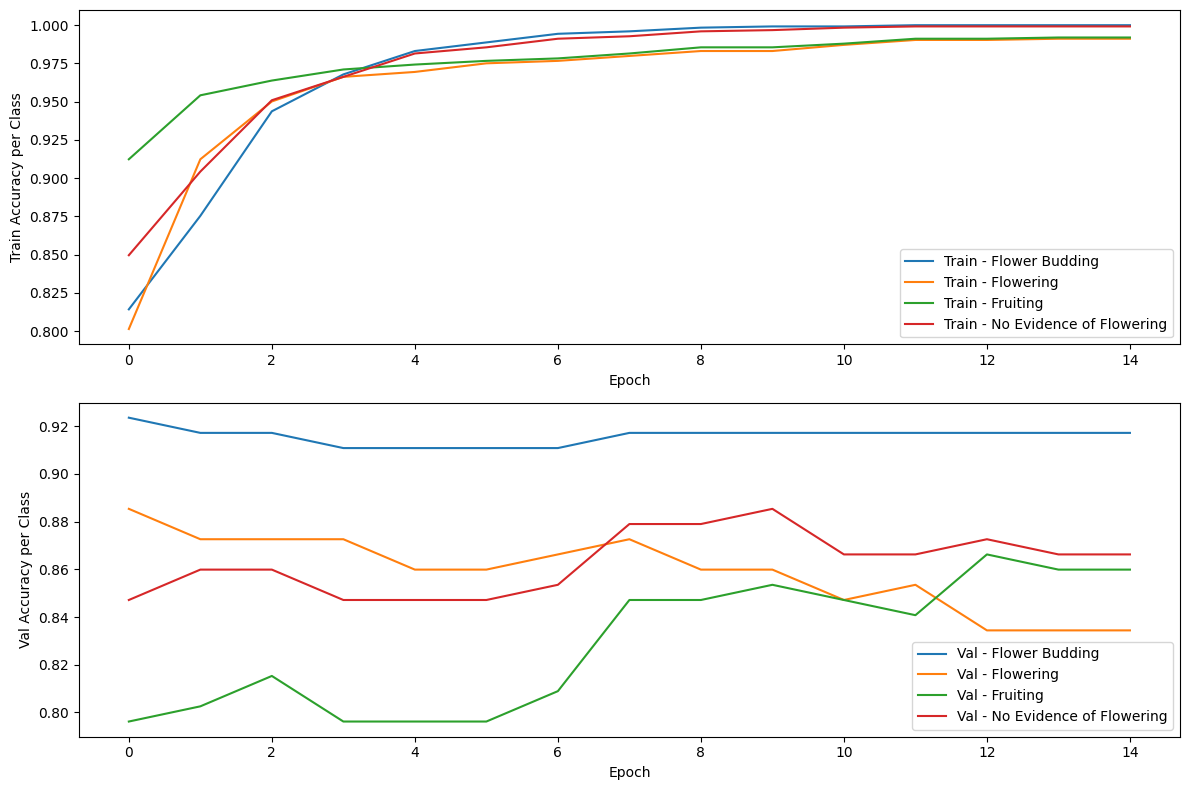

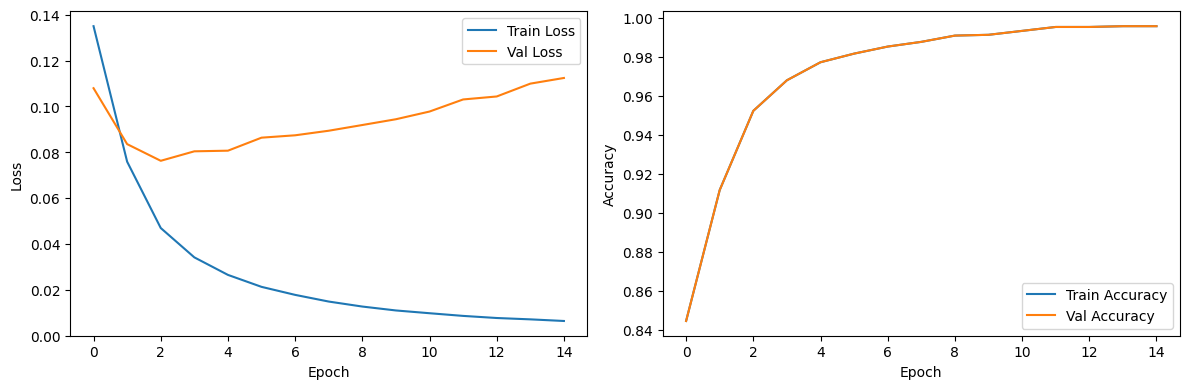

-> Evaluating classifier...
                          precision    recall  f1-score   support

          Flower Budding       0.00      0.00      0.00        12
               Flowering       0.77      0.95      0.85        78
                Fruiting       0.68      0.88      0.77        41
No Evidence of Flowering       0.86      0.23      0.36        26

               micro avg       0.74      0.74      0.74       157
               macro avg       0.58      0.51      0.50       157
            weighted avg       0.70      0.74      0.68       157
             samples avg       0.74      0.74      0.74       157



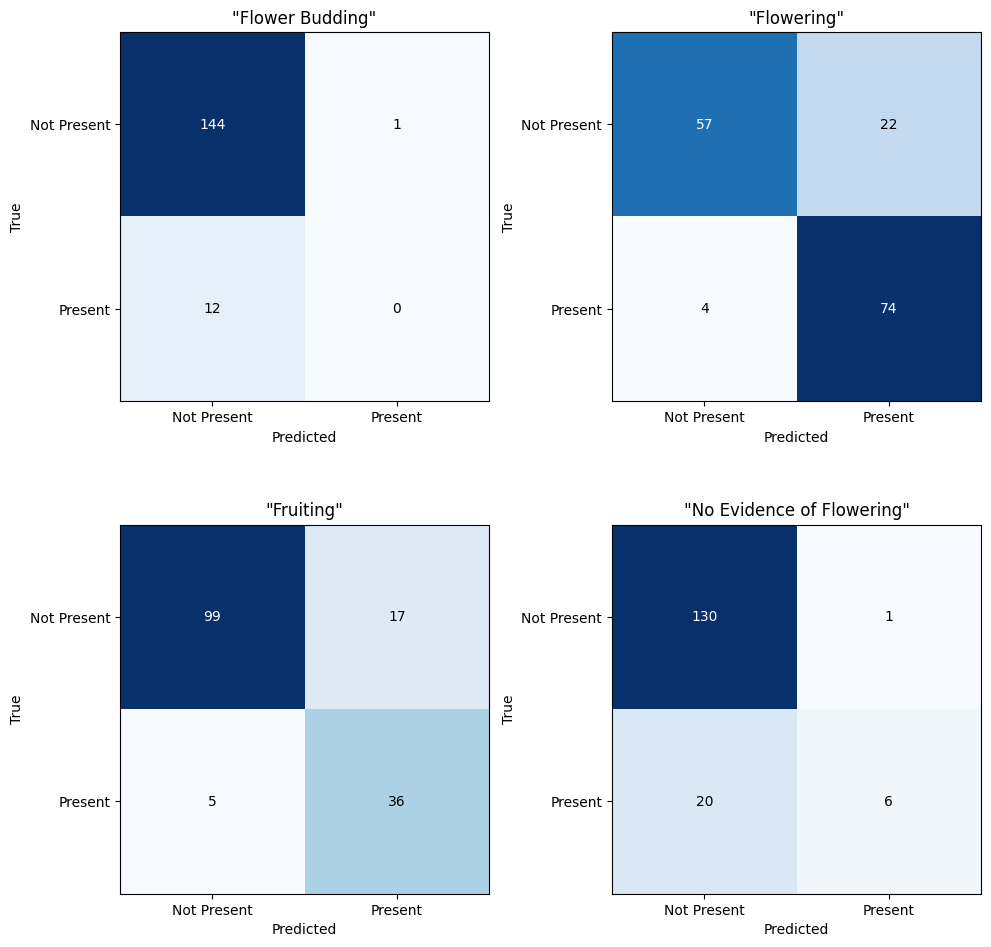

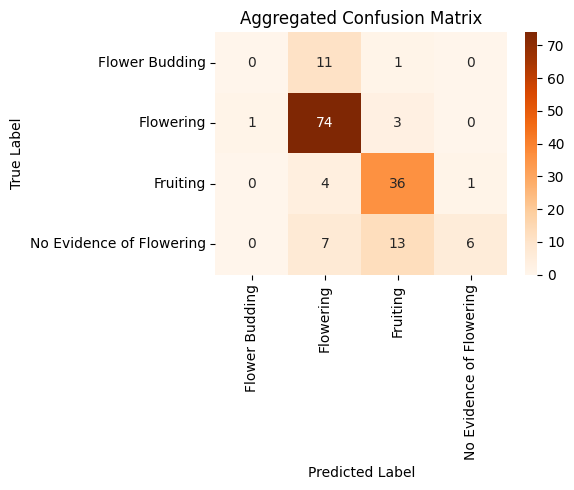

-> Predicting unlabeled data...
Successfully updated phenology data!


In [ ]:
create_model_and_predict('PROVA_fragola_verde')

Using device: cuda
-> Getting bioclip embeddings extractor model...
Total observations: 22671
Labeled observations: 8282
Unlabeled observations: 14389
Training set size: 6625
Validation set size: 1657
max count: 2730
minority classes: ['No Evidence of Flowering']
distribution: Counter({'Flowering': 2730, 'Fruiting': 2389, 'Flower Budding': 1406, 'No Evidence of Flowering': 100})
-> Extracting embeddings...
Using SMOTE: generating synthetic embeddings...
Original labels indices: [0 1 2 ... 1 2 1]
Minority classes: ['No Evidence of Flowering']
Minority class indices: {3}
Original class distribution: {np.int64(0): 1406, np.int64(1): 2730, np.int64(2): 2389, np.int64(3): 100}
Target count for minority classes: 300
SMOTE sampling strategy: {3: 300}
Final class distribution after SMOTE: {np.int64(0): 1406, np.int64(1): 2730, np.int64(2): 2389, np.int64(3): 300}
-> Extracting embeddings...
-> Extracting embeddings...
-> Training classifier...
Epoch 1/15: Train Loss: 0.0796, Validation Loss: 0

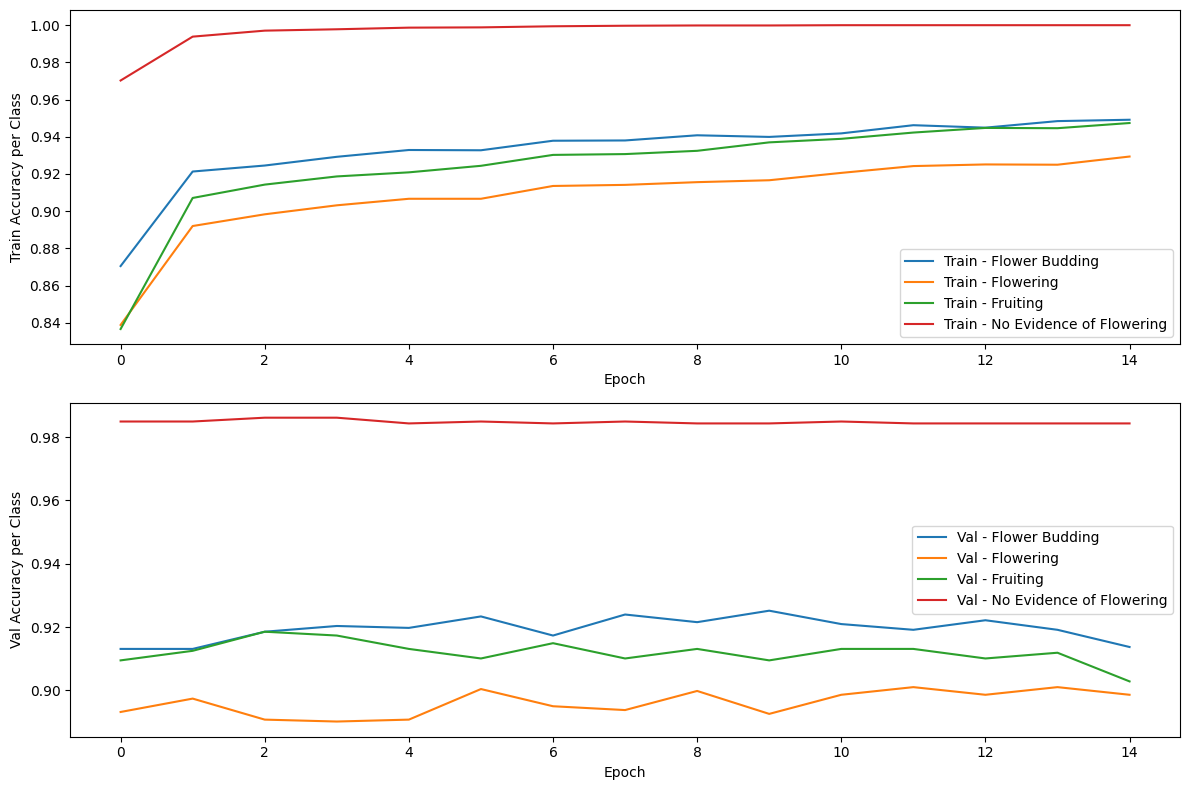

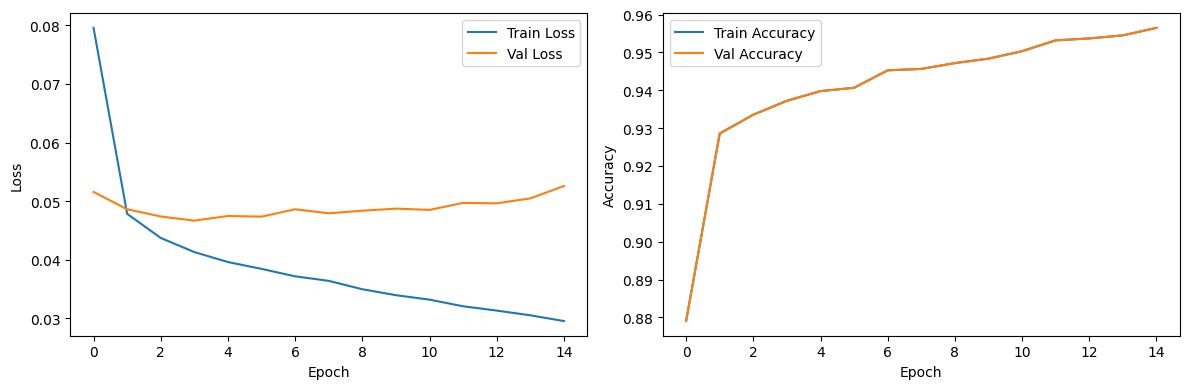

-> Evaluating classifier...
                          precision    recall  f1-score   support

          Flower Budding       0.75      0.89      0.81       351
               Flowering       0.89      0.86      0.88       683
                Fruiting       0.88      0.84      0.86       598
No Evidence of Flowering       0.33      0.04      0.07        25

               micro avg       0.85      0.85      0.85      1657
               macro avg       0.71      0.66      0.66      1657
            weighted avg       0.85      0.85      0.85      1657
             samples avg       0.85      0.85      0.85      1657



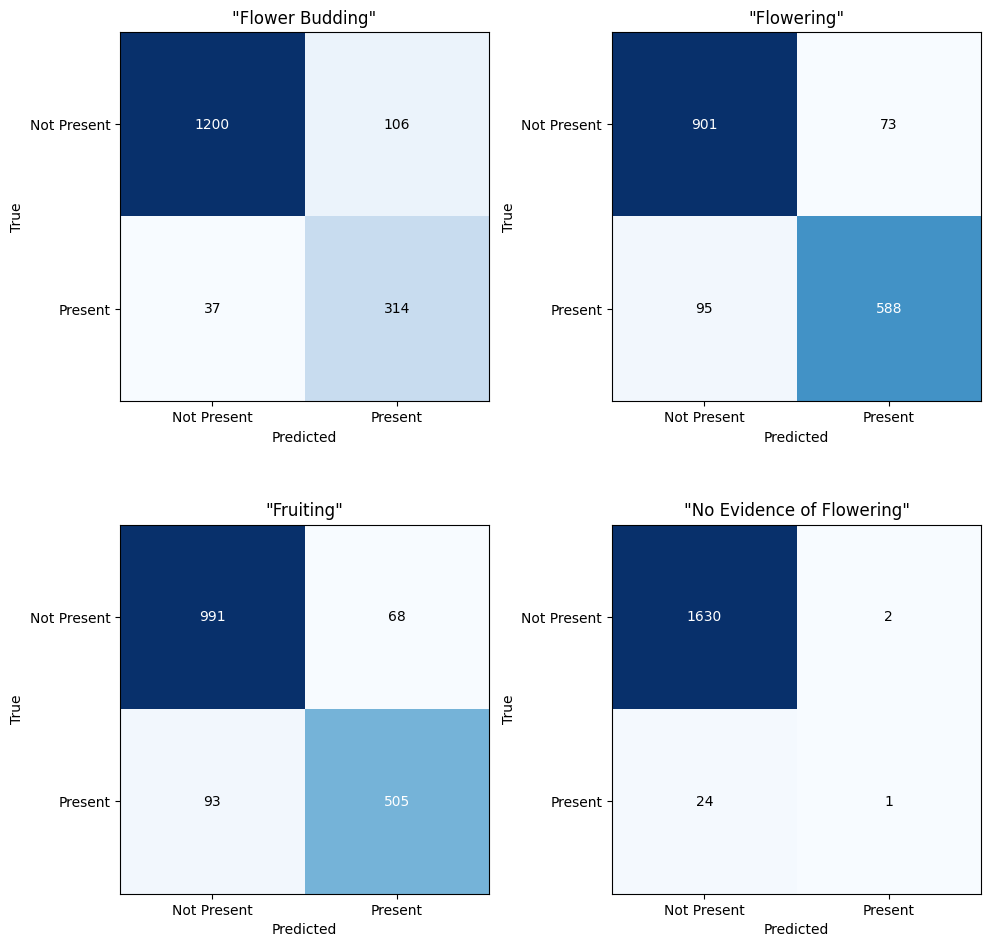

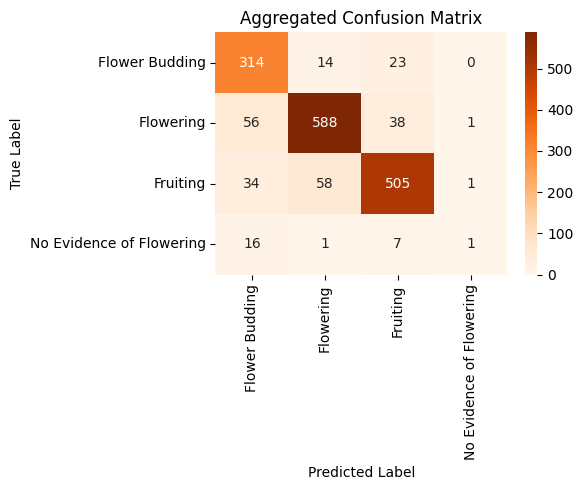

-> Predicting unlabeled data...
Successfully updated phenology data!


In [ ]:
create_model_and_predict('complete_dactylis_glomerata_n_a')

Using device: cuda
-> Getting bioclip embeddings extractor model...
Total observations: 80507
Labeled observations: 9373
Unlabeled observations: 71134
Training set size: 7498
Validation set size: 1875
max count: 6550
minority classes: ['No Evidence of Flowering', 'Fruiting', 'Flower Budding']
distribution: Counter({'Flowering': 6550, 'No Evidence of Flowering': 473, 'Flower Budding': 284, 'Fruiting': 191})
-> Extracting embeddings...
Using SMOTE: generating synthetic embeddings...
Original labels indices: [1 1 1 ... 1 2 1]
Minority classes: ['No Evidence of Flowering', 'Fruiting', 'Flower Budding']
Minority class indices: {0, 2, 3}
Original class distribution: {np.int64(1): 6550, np.int64(2): 191, np.int64(3): 473, np.int64(0): 284}
SMOTE sampling strategy: {0: 852, 2: 573, 3: 1419}
Final class distribution after SMOTE: {np.int64(1): 6550, np.int64(2): 573, np.int64(3): 1419, np.int64(0): 852}
-> Extracting embeddings...
-> Extracting embeddings...
-> Training classifier...
Epoch 1/15:

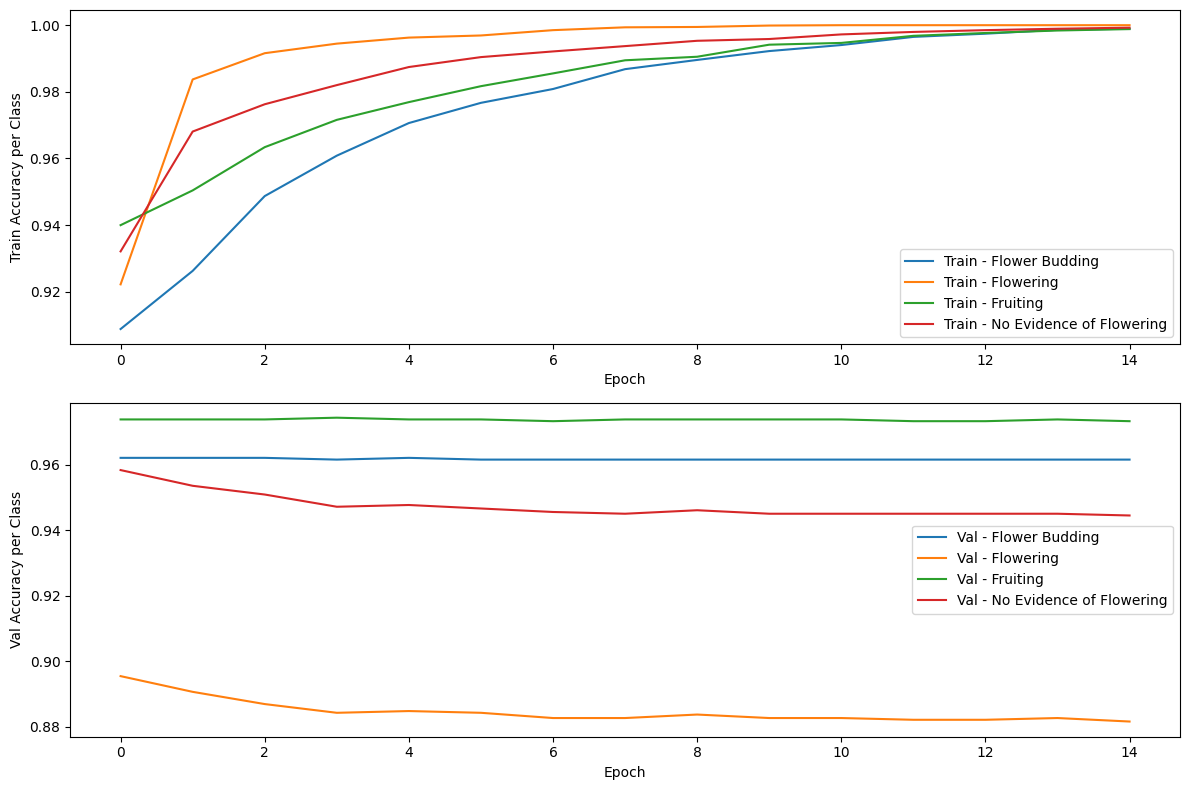

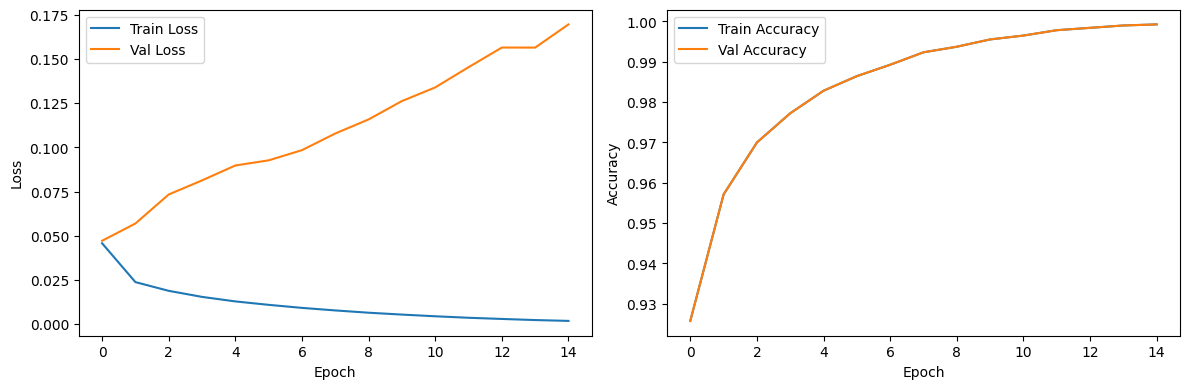

-> Evaluating classifier...
                          precision    recall  f1-score   support

          Flower Budding       0.33      0.01      0.03        71
               Flowering       0.88      1.00      0.94      1638
                Fruiting       0.00      0.00      0.00        48
No Evidence of Flowering       0.94      0.13      0.22       118

               micro avg       0.88      0.88      0.88      1875
               macro avg       0.54      0.28      0.30      1875
            weighted avg       0.84      0.88      0.83      1875
             samples avg       0.88      0.88      0.88      1875



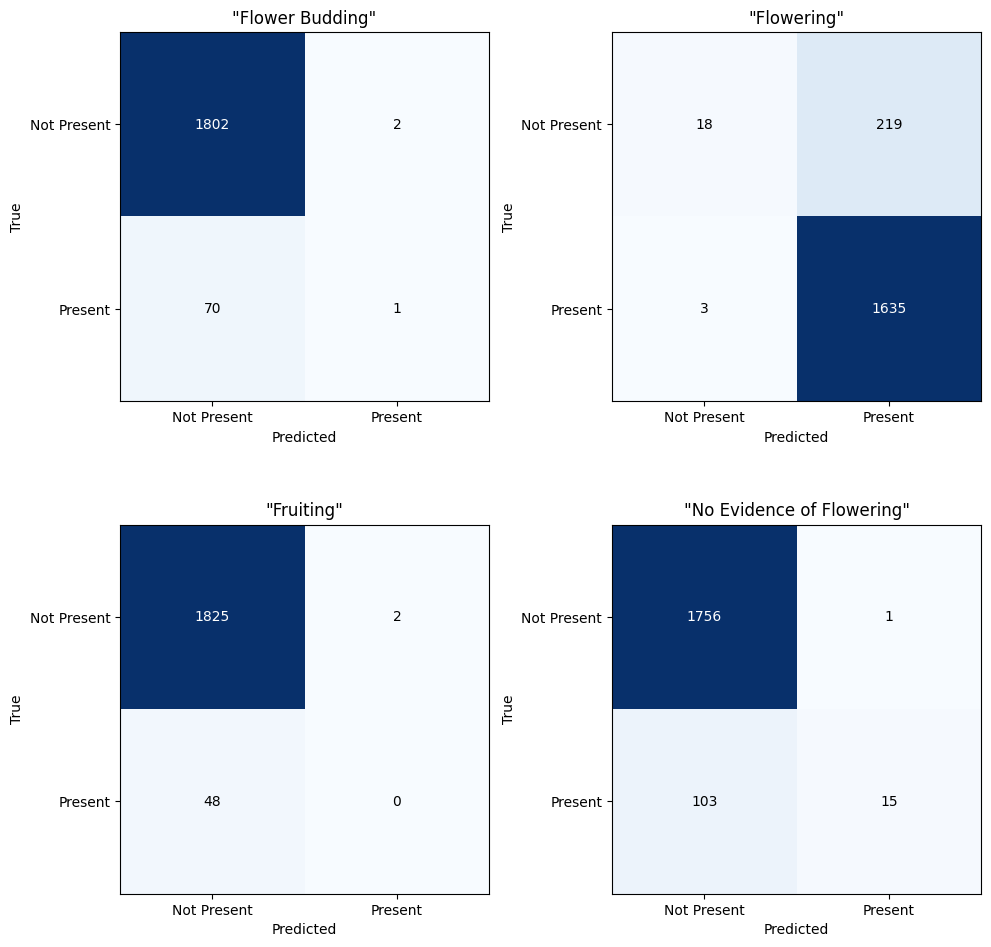

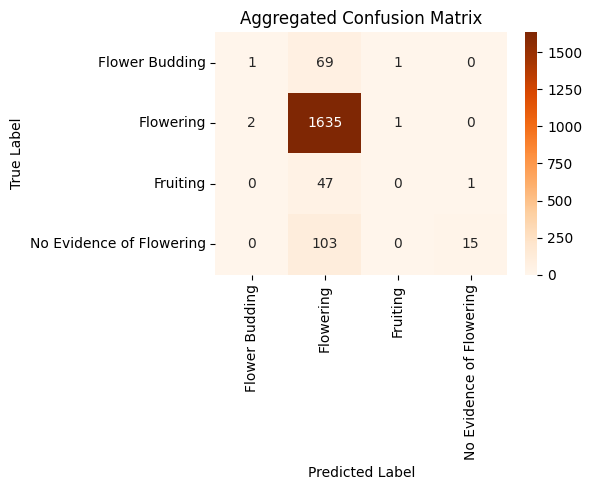

-> Predicting unlabeled data...
Successfully updated phenology data!


In [ ]:
create_model_and_predict('complete_trifolium_pratense_n_a')